خواندن دیتاست‌ها
تعداد ایمیل‌های فینگلیش: 45
تعداد ایمیل‌های دیتاست اصلی: 1000
تعداد ایمیل‌های اضافه: 300
تعداد ایمیل‌های تست استاد: 24
دیتاست نهایی آموزش
تعداد کل: 1345

توزیع کلاس‌ها:
label
0    675
1    670
Name: count, dtype: int64

تعداد ایمیل‌های تکراری: 0
تعداد بعد از حذف تکراری‌ها: 1345

نمونه قبل و بعد از نرمال‌سازی:

قبل:
﻿ممنون آقا سامان.
من پارسال اصلا آزاد شرکت نکرده بودم و سراسری هم قبول نشدم. فقط میخواستم بدونم شرایط چطوریه واسه سال بعد. مرسی از راهنمایی هاتون.

بعد:
﻿ممنون آقا سامان. من پارسال اصلا آزاد شرکت نکرده بودم و سراسری هم قبول نشدم. فقط میخواستم بدونم شرایط چطوریه واسه سال بعد. مرسی از راهنمایی هاتون.

قبل:
﻿سلام آقای کریمی
بالاخره آزمونارشد تموم شد من راحت شدم
یکم راهنمایی می خوام
بهترین مجله ی تخصصی زبان شناسی که بتونم اشتراک بگیرم کدومه؟
و در زمینه ی جامعه شناسی و روانشناسی زبان کتابای خوب و مرجع رو لطفا بهم معرفی کنید. صرفا به خاطر علاقه ی خودم می خوام مطالعه ی آزاد و تخصصی داشته باشم برای کنکور نیست
مرسی
دوستان دیگه هم اگه کمک کنند ممنونمی شم 

بعد:
﻿سلام 

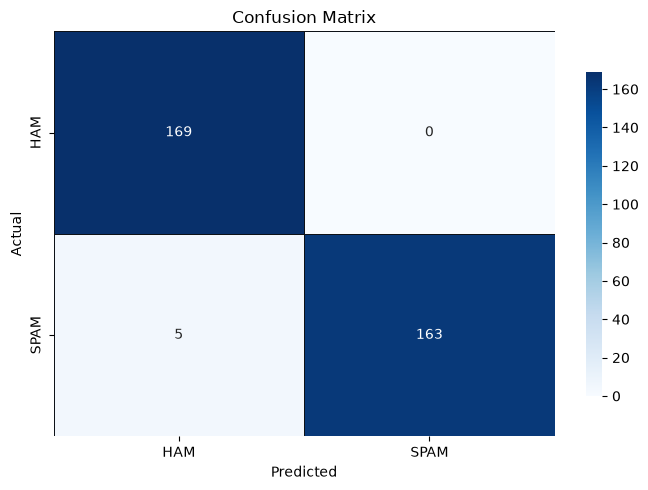

تحلیل احتمال‌ها
کمترین احتمال SPAM: 0.0111
بیشترین احتمال SPAM: 0.9977
میانگین احتمال SPAM: 0.4948
درصد پیش‌بینی‌های با اطمینان بالا: 84.57 %
تعداد پیش بینی های اشتباه :5
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

['spam_model.joblib']

In [2]:
import re
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


ARABIC_TO_PERSIAN = {
    "ي": "ی",
    "ى": "ی",
    "ك": "ک",
    "ة": "ه",
    "ؤ": "و",
    "إ": "ا",
    "أ": "ا",
    "ٱ": "ا",
    "ئ": "ی",
    "ۀ": "ه"
}

PERSIAN_DIGITS = str.maketrans("۰۱۲۳۴۵۶۷۸۹","0123456789")
ARABIC_DIGITS = str.maketrans("٠١٢٣٤٥٦٧٨٩","0123456789")
DIACRITICS = re.compile(r"[\u064B-\u065F\u0610-\u061A\u06D6-\u06ED]")
URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+|\S+\.(?:com|ir|net|org|biz|info)"r"(?:/\S*)?)",re.IGNORECASE)
PHONE_PATTERN = re.compile(r"(?:\+?98|0098|0)?9\d{9}\b")
EMOJI_MAP = {
    "😀": " EMOJI_HAPPY ",
    "😃": " EMOJI_HAPPY ",
    "😄": " EMOJI_HAPPY ",
    "😁": " EMOJI_HAPPY ",
    "😂": " EMOJI_LAUGH ",
    "🤣": " EMOJI_LAUGH ",
    "😍": " EMOJI_LOVE ",
    "❤️": " EMOJI_LOVE ",
    "❤": " EMOJI_LOVE ",
    "💕": " EMOJI_LOVE ",
    "😢": " EMOJI_SAD ",
    "😭": " EMOJI_SAD ",
    "😡": " EMOJI_ANGRY ",
    "😠": " EMOJI_ANGRY ",
    "🎉": " EMOJI_CELEBRATE ",
    "🎊": " EMOJI_CELEBRATE ",
    "💰": " EMOJI_MONEY ",
    "💵": " EMOJI_MONEY ",
    "💸": " EMOJI_MONEY ",
    "🤑": " EMOJI_MONEY ",
    "🔥": " EMOJI_FIRE ",
    "⚡": " EMOJI_FIRE ",
    "✅": " EMOJI_CHECK ",
    "✔️": " EMOJI_CHECK ",
    "⚠️": " EMOJI_WARNING ",
    "❗": " EMOJI_WARNING ",
    "‼️": " EMOJI_WARNING ",
    "👍": " EMOJI_LIKE ",
    "👏": " EMOJI_LIKE ",
    "🎁": " EMOJI_GIFT ",
    "🏆": " EMOJI_GIFT ",
    "📞": " EMOJI_PHONE ",
    "☎️": " EMOJI_PHONE ",
    "🔗": " EMOJI_LINK "
}

EMOJI_CATCH_ALL = re.compile(
    "[\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "\U0001F1E6-\U0001F1FF]+",
    flags=re.UNICODE)

def fix_elongation(text):
    return re.sub(r"(.)\1{2,}", r"\1", text)

def normalize_persian_text(text):
    if not isinstance(text, str):
        return ""
    text = str(text)
    for arabic, persian in ARABIC_TO_PERSIAN.items():
        text = text.replace(arabic, persian)
    text = DIACRITICS.sub("", text)
    text = text.translate(PERSIAN_DIGITS)
    text = text.translate(ARABIC_DIGITS)
    text = text.replace("\u200c", " ")
    text = text.replace("\u200f", " ")
    text = text.replace("\u200e", " ")

    for emoji, token in EMOJI_MAP.items():
        text = text.replace(emoji, token)
    text = EMOJI_CATCH_ALL.sub(" EMOJI_OTHER ", text)
    text = URL_PATTERN.sub(" URL_TOKEN ", text)
    text = PHONE_PATTERN.sub(" PHONE_TOKEN ", text)
    text = re.sub(r"\d+", " NUMBER_TOKEN ", text)
    text = fix_elongation(text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()



print("خواندن دیتاست‌ها")
df_main = pd.read_csv("emails.csv")
df_extra = pd.read_csv("extra_emails_300.csv")
df_professor = pd.read_csv("test_emails_24.csv")
df_finglish = pd.read_csv("finglish_extra.csv") 

print("تعداد ایمیل‌های فینگلیش:", len(df_finglish))
print("تعداد ایمیل‌های دیتاست اصلی:",len(df_main))
print("تعداد ایمیل‌های اضافه:",len(df_extra))
print("تعداد ایمیل‌های تست استاد:",len(df_professor))



def clean_label(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    mapping = {
        "spam": 1,
        "ham": 0,
        
        "1": 1,
        "0": 0,
        
        "اسپم": 1,
        "هرزنامه": 1,
        
        "سالم": 0,
        "عادی": 0
    }

    return mapping.get(value, np.nan)

df_main["label"] = df_main["label"].apply(clean_label)
df_extra["label"] = df_extra["label"].apply(clean_label)
df_finglish["label"] = df_finglish["label"].apply(clean_label)
df_professor["label"] = df_professor["label"].apply(clean_label)



if df_main["label"].isna().sum() > 0:
    print("\nتعداد Label نامعتبر در دیتاست اصلی:", df_main["label"].isna().sum())
    raise ValueError("در emails.csv برچسب نامعتبر وجود دارد.")

if df_extra["label"].isna().sum() > 0:
    print("\nتعداد Label نامعتبر در دیتاست اضافه:", df_extra["label"].isna().sum())
    raise ValueError("در extra_emails_300.csv برچسب نامعتبر وجود دارد.")
    
if df_finglish["label"].isna().sum() > 0:
    print("\nتعداد Label نامعتبر در دیتاست فینگلیش:", df_finglish["label"].isna().sum())
    raise ValueError("درفینگلیش برچسب نامعتبر وجود دارد.")
    
if df_professor["label"].isna().sum() > 0:
    print("\nتعداد Label نامعتبر در تست استاد:", df_professor["label"].isna().sum())
    raise ValueError("در test_emails_24.csv برچسب نامعتبر وجود دارد.")

df_main = df_main.dropna(subset=["text", "label"])
df_extra = df_extra.dropna(subset=["text", "label"])
df_finglish = df_finglish.dropna(subset=["text", "label"])
df_professor = df_professor.dropna(subset=["text", "label"])


df_main["label"] = df_main["label"].astype(int)
df_extra["label"] = df_extra["label"].astype(int)
df_finglish["label"] = df_finglish["label"].astype(int)   
df_professor["label"] = df_professor["label"].astype(int)

df = pd.concat([
        df_main[["text", "label"]],
        df_extra[["text", "label"]],
        df_finglish[["text", "label"]]
    ],ignore_index=True)

print("دیتاست نهایی آموزش")
print("تعداد کل:",len(df))
print("\nتوزیع کلاس‌ها:")
print(df["label"].value_counts())

duplicate_count = df.duplicated(subset=["text"]).sum()
print("\nتعداد ایمیل‌های تکراری:", duplicate_count)

df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print("تعداد بعد از حذف تکراری‌ها:",len(df))


df["clean_text"] = df["text"].apply(normalize_persian_text)
df_professor["clean_text"] = df_professor["text"].apply(normalize_persian_text)
print("\nنمونه قبل و بعد از نرمال‌سازی:")

for i in range(min(3, len(df))):
    print("\nقبل:")
    print(df.iloc[i]["text"])
    print("\nبعد:")
    print(df.iloc[i]["clean_text"])


X = df["clean_text"]

y = df["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("Train:", len(X_train))
print("Test:", len(X_test))
print("\nتوزیع Train:")
print(y_train.value_counts())
print("\nتوزیع Test:")
print(y_test.value_counts())



vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)


X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("تعداد ویژگی‌ها:", len(vectorizer.get_feature_names_out()))

print("BASELINE")

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_vec, y_train)
dummy_pred = dummy.predict(X_test_vec)
dummy_accuracy = accuracy_score(y_test, dummy_pred) 
print(f"Dummy Accuracy: {dummy_accuracy:.4f}")


def http_rule(text):
    if not isinstance(text, str):
        return 0
    return int(
        "http" in text.lower()
    )
rule_pred = X_test.apply(http_rule)
rule_accuracy = accuracy_score(y_test, rule_pred)
print(f"HTTP Rule Accuracy: {rule_accuracy:.4f}")


model = LogisticRegression(
    C=10,
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

model.fit(X_train_vec,y_train)
pred = model.predict(X_test_vec)
proba = model.predict_proba(X_test_vec)[:, 1]


accuracy = accuracy_score(y_test,pred)
precision = precision_score(y_test,pred)
recall = recall_score(y_test,pred)
f1 = f1_score(y_test,pred)

print("نتایج اصلی مدل")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

cm = confusion_matrix(y_test,pred)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix:{cm}")

print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


print(f"ایمیل سالم که اشتباهی SPAM شده: {fp}")
print(f"ایمیل SPAM که اشتباهی HAM شده: {fn}")


plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["HAM", "SPAM"],
    yticklabels=["HAM", "SPAM"],
    linewidths=0.5,
    linecolor="#0d1117",
    cbar_kws={"shrink": 0.8}
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


print("تحلیل احتمال‌ها")
print("کمترین احتمال SPAM:",round(proba.min(),4))
print("بیشترین احتمال SPAM:",round(proba.max(),4))
print("میانگین احتمال SPAM:", round(proba.mean(),4))
print("درصد پیش‌بینی‌های با اطمینان بالا:",round((((proba >= 0.90) |(proba <= 0.10)).mean()) * 100,2),"%")


results = pd.DataFrame({
    "text": X_test.values,
    "real": y_test.values,
    "pred": pred,
    "spam_probability": proba,
})


wrong_predictions = results[
    results["real"] != results["pred"]
]


print(f"تعداد پیش بینی های اشتباه :{len(wrong_predictions)}")


if len(wrong_predictions) > 0:
    print(wrong_predictions.to_string(index=False))
else:
    print("مدل هیچ ایمیلی را در Test اشتباه نکرده است.")



print("5-FOLD CROSS VALIDATION")

cv_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_all_vec = cv_vectorizer.fit_transform(X)

cv_model = LogisticRegression(
    C=10,
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

cv_scores = cross_val_score(
    cv_model,
    X_all_vec,
    y,
    cv=5,
    scoring="accuracy"
)

print("امتیازهای 5 Fold:")
print(np.round(cv_scores,4))
print("میانگین:",round(cv_scores.mean(),4))
print("انحراف معیار:",round(cv_scores.std(),4))

print("تست نهایی 24 ایمیل استاد")
professor_vec = vectorizer.transform(df_professor["clean_text"])
professor_pred = model.predict(professor_vec)
professor_proba = model.predict_proba(professor_vec)
df_professor["prediction"] = professor_pred

df_professor["ham_probability"] = (professor_proba[:, 0] * 100).round(2)
df_professor["spam_probability"] = (professor_proba[:, 1] * 100).round(2)

df_professor["result"] = df_professor["prediction"].map({
    0: "HAM",
    1: "SPAM"
})

df_professor["correct"] = (df_professor["prediction"] == df_professor["label"])

columns_to_show = [
    "text",
    "label",
    "result",
    "ham_probability",
    "spam_probability",
    "correct"
]


if "level" in df_professor.columns:
    columns_to_show.insert(1,"level")
    
print(df_professor[columns_to_show].to_string(index=False))


professor_accuracy = accuracy_score(
    df_professor["label"], df_professor["prediction"])

professor_precision = precision_score(
    df_professor["label"], df_professor["prediction"])

professor_recall = recall_score(
    df_professor["label"], df_professor["prediction"])

professor_f1 = f1_score(
    df_professor["label"], df_professor["prediction"])

print("نتایج تست 24 ایمیل استاد")
print(f"Accuracy : {professor_accuracy:.4f}")
print(f"Precision: {professor_precision:.4f}")
print(f"Recall   : {professor_recall:.4f}")
print(f"F1 Score : {professor_f1:.4f}")

professor_cm = confusion_matrix(
    df_professor["label"], df_professor["prediction"])
print(f"Confusion Matrix:{professor_cm}")

if "level" in df_professor.columns:
    print("عملکرد بر اساس سطح")

    level_values = (df_professor["level"].dropna().unique())
    for level in level_values:
        level_data = df_professor[df_professor["level"] == level]
        level_accuracy = accuracy_score(level_data["label"], level_data["prediction"])
        level_precision = precision_score(level_data["label"], level_data["prediction"])
        level_recall = recall_score(level_data["label"], level_data["prediction"])
        level_f1 = f1_score(level_data["label"], level_data["prediction"])

        print(f"\nسطح: {level}")
        print("تعداد:",len(level_data))
        print(f"Accuracy : {level_accuracy:.4f}")
        print(f"Precision: {level_precision:.4f}")
        print(f"Recall   : {level_recall:.4f}")
        print(f"F1 Score : {level_f1:.4f}")

professor_wrong = df_professor[df_professor["correct"] == False]

print("اشتباهات مدل در تست استاد")
print("تعداد اشتباه:", len(professor_wrong))

if len(professor_wrong) > 0:
    print(professor_wrong[columns_to_show].to_string(index=False))
else:
    print("هیچ اشتباهی وجود ندارد.")


model_package = {
    "model":model,
    "vectorizer":vectorizer,
    "normalize_function":normalize_persian_text
}

joblib.dump(model_package,"spam_model.joblib")